# Exact Heston Model Simulations for Characteristic Function Methods

## Overview

This notebook uses the exact simulation method from {cite:t}`BroadieKaya2006`. All implementations are in `utils.py`.

The critical step is sampling the integrated variance $\int_0^T V_s \, ds$, which requires inverting its CDF. We compare how different CF recovery methods (COS, Carr-Madan, CONV) handle this inversion.

The COS method is fastest and most stable. Carr-Madan can produce near-zero PDFs that break Newton's method. CONV is slowest due to convolution overhead.

In [1]:
from utils import *


=== Testing COS Method ===
Using cos method for CDF recovery and inversion
Computation time: 0.120 seconds
Min integrated variance: 0.00000000
Values <= 1e-10: 4/204
All positive: False

=== Testing CARR_MADAN Method ===
Using carr_madan method for CDF recovery and inversion
Computation time: 2.518 seconds
Min integrated variance: 0.00000000
Values <= 1e-10: 4/204
All positive: False

=== Testing CONV Method ===
Using conv method for CDF recovery and inversion
Computation time: 5.391 seconds
Min integrated variance: 0.00000000
Values <= 1e-10: 4/204
All positive: False


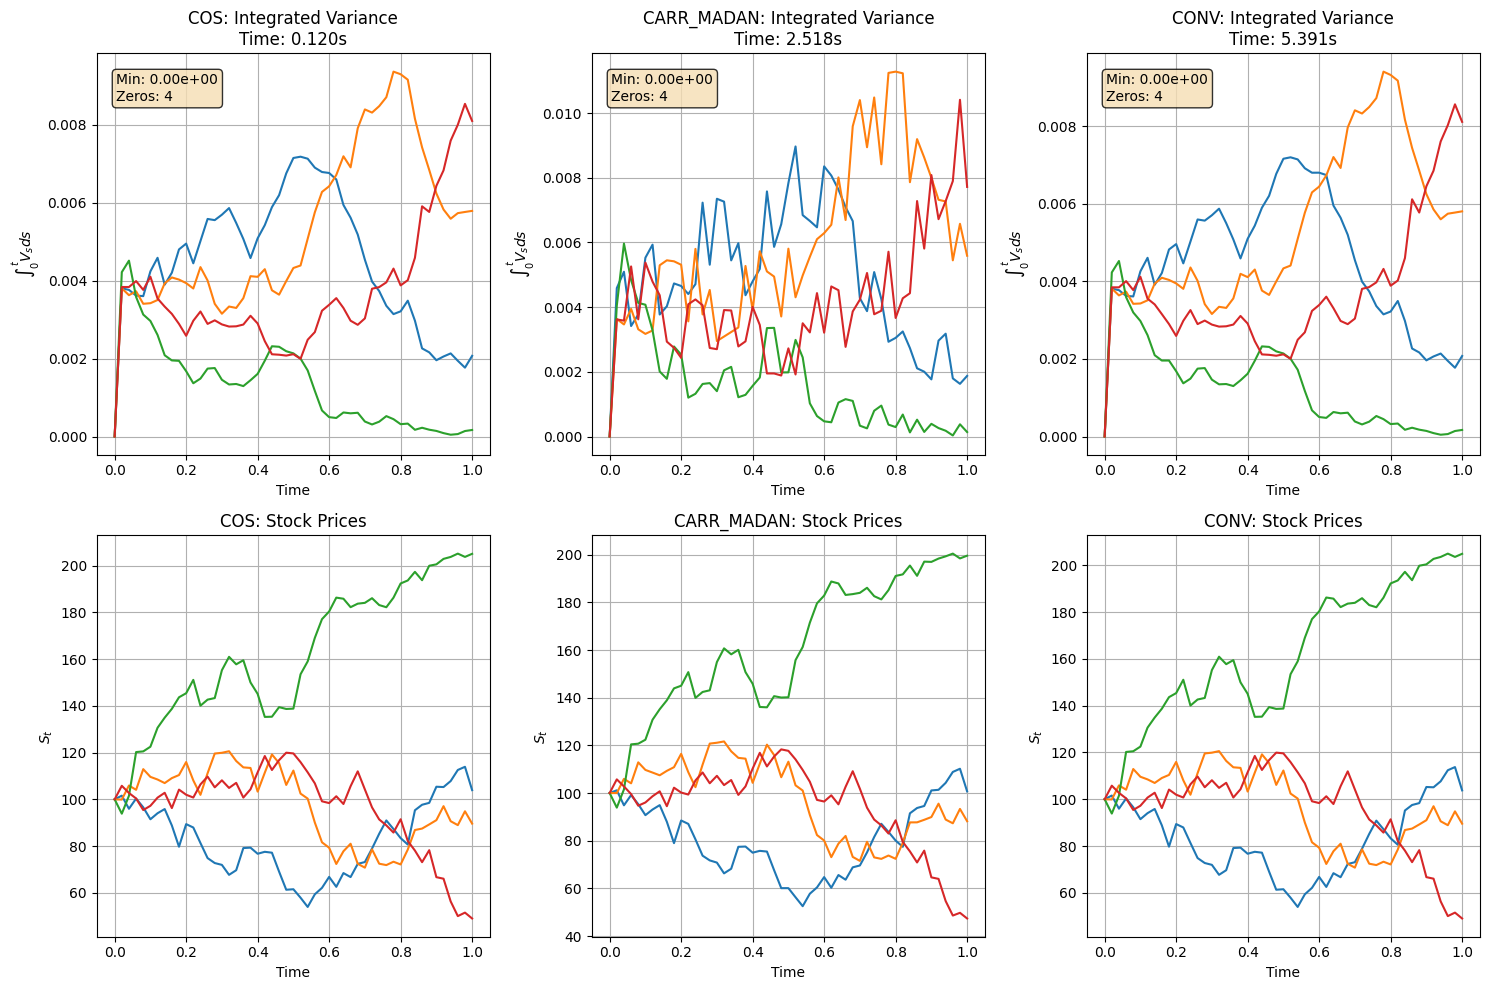


=== Performance Comparison ===
COS: 0.120 seconds
CARR_MADAN: 2.518 seconds
CONV: 5.391 seconds

=== Zero Analysis ===
COS: min=0.00000000, zeros(<=1e-10)=4, exact_zeros=4
CARR_MADAN: min=0.00000000, zeros(<=1e-10)=4, exact_zeros=4
CONV: min=0.00000000, zeros(<=1e-10)=4, exact_zeros=4


In [2]:
if __name__ == "__main__":
    # Parameters
    NoOfPaths = 4
    NoOfSteps = 50

    
    # Heston model parameters
    gamma = 0.4 # vol of vol
    kappa = 0.5 # speed of mean reversion
    vbar = 0.2 # long-term mean
    rho = -0.9 # negative correlation
    v0 = 0.2 # initial variance
    T = 1.0
    S_0 = 100.0
    r = 0.1
    
    nr_expansion = 100
    L = 10
    
    # Set random seed for reproducibility
    np.random.seed(3)
    
    # Test all three methods
    methods_to_test = {
        "cos": {},
        "carr_madan": {"N": 2**12},
        "conv": {"alpha": 0.5, "N": 2**13}
    }
    
    results = {}
    
    for method_name, kwargs in methods_to_test.items():
        print(f"\n=== Testing {method_name.upper()} Method ===")
        
        # Reset random seed to ensure fair comparison
        np.random.seed(3)
        
        start_time = time.time()
        paths = GeneratePathsHestonES(
            NoOfPaths, NoOfSteps, T, r, S_0, kappa, gamma, rho, vbar, v0,
            nr_expansion=nr_expansion, L=L, recovery_method=method_name, **kwargs
        )
        end_time = time.time()
        
        results[method_name] = {
            "paths": paths,
            "computation_time": end_time - start_time
        }
        
        # Check for zeros in integrated variance
        V_int = paths["Vint"]
        min_vint = np.min(V_int)
        zero_count = np.sum(V_int <= 1e-10)
        
        print(f"Computation time: {end_time - start_time:.3f} seconds")
        print(f"Min integrated variance: {min_vint:.8f}")
        print(f"Values <= 1e-10: {zero_count}/{V_int.size}")
        print(f"All positive: {np.all(V_int > 0)}")
    
    # Plot comparison
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for idx, (method_name, result) in enumerate(results.items()):
        timeGrid = result["paths"]["time"]
        S = result["paths"]["S"]
        V_int = result["paths"]["Vint"]
        
        # Plot integrated variance
        axes[0, idx].grid(True)
        axes[0, idx].plot(timeGrid, np.transpose(V_int))
        axes[0, idx].set_xlabel('Time')
        axes[0, idx].set_ylabel(r'$\int_0^t V_s ds$')
        axes[0, idx].set_title(f'{method_name.upper()}: Integrated Variance\nTime: {result["computation_time"]:.3f}s')
        
        # Add text showing min value and zero count
        min_val = np.min(V_int)
        zero_count = np.sum(V_int <= 1e-10)
        axes[0, idx].text(0.05, 0.95, f'Min: {min_val:.2e}\nZeros: {zero_count}', 
                         transform=axes[0, idx].transAxes, verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Plot stock price paths
        axes[1, idx].grid(True)
        axes[1, idx].plot(timeGrid, np.transpose(S))
        axes[1, idx].set_xlabel('Time')
        axes[1, idx].set_ylabel(r'$S_t$')
        axes[1, idx].set_title(f'{method_name.upper()}: Stock Prices')
    
    plt.tight_layout()
    plt.show()
    
    # Print timing comparison
    print("\n=== Performance Comparison ===")
    for method_name, result in results.items():
        print(f"{method_name.upper()}: {result['computation_time']:.3f} seconds")
    
    # Print zero analysis
    print("\n=== Zero Analysis ===") # 4 zeros since we start from 0 for each path, 4 paths give 4 0s
    for method_name, result in results.items():
        V_int = result["paths"]["Vint"]
        min_val = np.min(V_int)
        zero_count = np.sum(V_int <= 1e-10)
        exact_zero_count = np.sum(V_int == 0.0)
        print(f"{method_name.upper()}: min={min_val:.8f}, zeros(<=1e-10)={zero_count}, exact_zeros={exact_zero_count}")


In [3]:
np.random.seed(19937)
paths = GeneratePathsHestonES(
    NoOfPaths=3, NoOfSteps=10, T=0.5, r=0.05, S_0=100,
    kappa=0.5, gamma=0.4, rho=-0.7, vbar=0.2, v0=0.2,
    nr_expansion=50, L=8, recovery_method='carr_madan', N=2048
)

min_vint = np.min(paths['Vint'])
zero_count = np.sum(paths['Vint'] < 1e-10)
print(f"Min integrated variance: {min_vint:.8f}")
print(f"Zero values: {zero_count}/{paths['Vint'].size}")
print(f"All values positive: {np.all(paths['Vint'] > 0)}")

# Show first few values
print(f"First few values: {paths['Vint'][:, :5]}")

# If we still see zeros, there's a problem with the import
if zero_count > 0:
    print("ERROR: Still seeing zeros! The fixed utils.py is not being used.")
    print("Please restart the Jupyter kernel and run all cells again.")
else:
    print("SUCCESS: No zeros found! The fix is working correctly.")

Using carr_madan method for CDF recovery and inversion
Min integrated variance: 0.00000000
Zero values: 3/33
All values positive: False
First few values: [[0.         0.00820748 0.01244002 0.0057766  0.00594043]
 [0.         0.01216596 0.00488744 0.00421276 0.00721748]
 [0.         0.01324573 0.00684683 0.00610532 0.01005199]]
ERROR: Still seeing zeros! The fixed utils.py is not being used.
Please restart the Jupyter kernel and run all cells again.


## Observations

**Speed:** COS is fastest (no integration), Carr-Madan is middle, CONV is slowest (convolution overhead).

**Stability:** Carr-Madan can produce near-zero PDFs, causing Newton's method to collapse. COS and CONV have built-in numerical stabilization.

**Stock paths:** All methods produce similar trajectories—the difference is in speed and numerical stability of the integrated variance sampling.

## Comparison

COS is the clear winner for this application. Fast, stable, and avoids integration. Beyond exact simulation, COS is useful for option pricing (replacing Monte Carlo), model calibration, and Greeks computation.

#### Newton-Raphson method vs. brute force approach for CDF inversion

/Users/patrikliba/QFB/utils.py:421: RuntimeWarning: invalid value encountered in scalar multiply
  chf = temp1 * temp2 * temp3 / temp4
/Users/patrikliba/QFB/utils.py:421: RuntimeWarning: invalid value encountered in scalar divide
  chf = temp1 * temp2 * temp3 / temp4
/Users/patrikliba/QFB/utils.py:387: RuntimeWarning: invalid value encountered in divide
  R
/Users/patrikliba/QFB/utils.py:398: RuntimeWarning: invalid value encountered in divide
  - R * (1 + np.exp(-R * tau)) / (1 - np.exp(-R * tau))
/Users/patrikliba/QFB/utils.py:405: RuntimeWarning: invalid value encountered in divide
  np.sqrt(vt * vu)


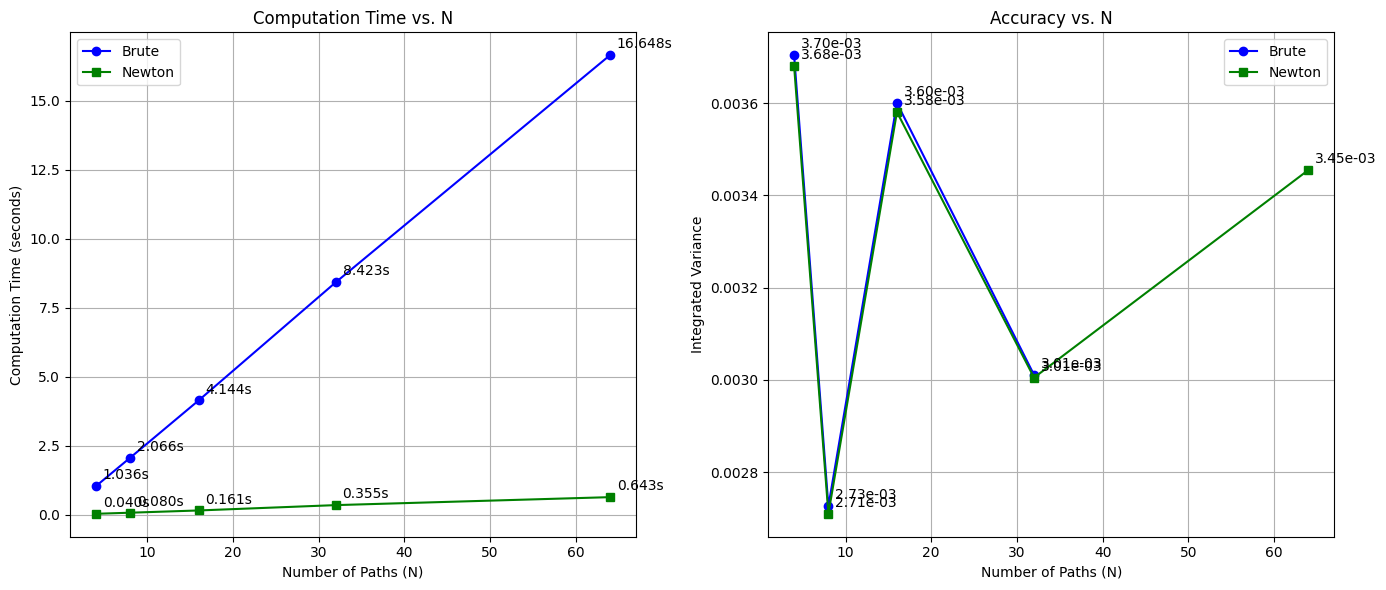

,N,Brute Time (s),Newton Time (s),vint_brute_values,vint_newton_values
0,4,1.036360,0.040464,0.003704,0.003680
1,8,2.066391,0.079768,0.002726,0.002710
2,16,4.144209,0.161133,0.003600,0.003581
3,32,8.423083,0.354710,0.003011,0.003005
4,64,16.647693,0.643156,NaN,0.003455


In [4]:
compare_cdf_inversion_methods()